In [21]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [22]:
# from src.llm_evaluation.llm.llm import call_llm
# response = call_llm("Return ONLY JSON: {\"test\": true}")
# print(response)

In [23]:
# from src.llm_evaluation.llm.llm import call_llm
# from src.llm_evaluation.llm.prompt_loader import load_prompt, build_prompt

# prompt = load_prompt("../prompts/prompt_v1.txt")
# final_prompt = build_prompt(prompt, "I think this product is great")

# response = call_llm(final_prompt)
# print(response)

In [25]:
import pandas as pd

from src.llm_evaluation.llm.llm import call_llm
from src.llm_evaluation.utils.parser import parse_json_response
from src.llm_evaluation.evaluation.metrics import evaluate_predictions

In [26]:
df = pd.read_csv("../data/dataset.csv")
df = df.sample(50, random_state=42)
df.head()

,text,label
203,atraparon de inmediato al poner blinding light...,neutral
266,identification modi supporter,neutral
152,modi againmodi undisputed leader ââï¸,neutral
9,omar abdullah mrs sara pilot inauguration nira...,positive
233,uttar pradesh deled student general category f...,negative


In [54]:
df.shape

(50, 2)

In [57]:
from langdetect import detect
df_all = pd.read_csv("../data/dataset.csv")


def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False

df_filtered = df_all[df_all["text"].apply(is_english)]

In [60]:
df_all.shape

(300, 2)

In [59]:
df_filtered.shape

(227, 2)

In [61]:
df = df_filtered.sample(50, random_state=42)

In [62]:
def run_experiment(prompt_path, output_path=None):

    with open(prompt_path, "r") as f:
        prompt_template = f.read()

    results = []

    for _, row in df.iterrows():

        text = row["text"]
        true_label = row["label"]

        prompt = prompt_template.replace("{text}", text)

        response = call_llm(prompt)

        parsed = parse_json_response(response)
        if parsed is None:
            continue

        results.append({
            "text": text,
            "true_label": true_label,
            "predicted_label": parsed.get("sentiment"),
            "confidence": parsed.get("confidence")
        })

    results_df = pd.DataFrame(results)

    metrics = evaluate_predictions(results_df)

    if output_path:
        results_df.to_csv(output_path, index=False)

    return results_df, metrics

In [63]:
results_v1, metrics_v1 = run_experiment(
    "../prompts/prompt_v1.txt",
    "../results/results_v1.csv"
)

results_v2, metrics_v2 = run_experiment(
    "../prompts/prompt_v2.txt",
    "../results/results_v2.csv"
)

results_v3, metrics_v3 = run_experiment(
    "../prompts/prompt_v3.txt",
    "../results/results_v3.csv"
)

In [64]:
print("V1:", metrics_v1)
print("V2:", metrics_v2)
print("V3:", metrics_v3)

V1: {'accuracy': 0.56, 'f1_macro': 0.5670787545787546, 'classification_report': '              precision    recall  f1-score   support\n\n    negative       0.30      0.78      0.44         9\n     neutral       0.60      0.82      0.69        11\n    positive       1.00      0.40      0.57        30\n\n    accuracy                           0.56        50\n   macro avg       0.63      0.67      0.57        50\nweighted avg       0.79      0.56      0.57        50\n'}
V2: {'accuracy': 0.46, 'f1_macro': 0.4447708578143361, 'classification_report': '              precision    recall  f1-score   support\n\n    negative       0.29      0.44      0.35         9\n     neutral       0.35      0.82      0.49        11\n    positive       1.00      0.33      0.50        30\n\n    accuracy                           0.46        50\n   macro avg       0.54      0.53      0.44        50\nweighted avg       0.73      0.46      0.47        50\n'}
V3: {'accuracy': 0.42, 'f1_macro': 0.41799215483426017

In [65]:
metrics_dict = {
    "V1": metrics_v1,
    "V2": metrics_v2,
    "V3": metrics_v3
}

results_dict = {
    "V1": results_v1,
    "V2": results_v2,
    "V3": results_v3
}

In [66]:
from src.llm_evaluation.evaluation.visualization import (
    plot_global_metrics,
    plot_label_distribution,
    plot_confusion_matrix
)

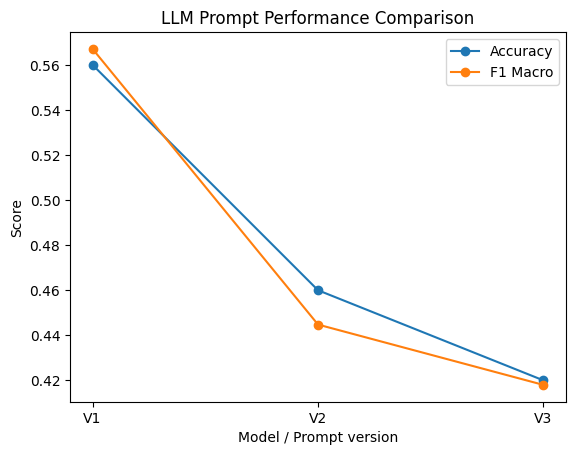

In [67]:
plot_global_metrics(metrics_dict)

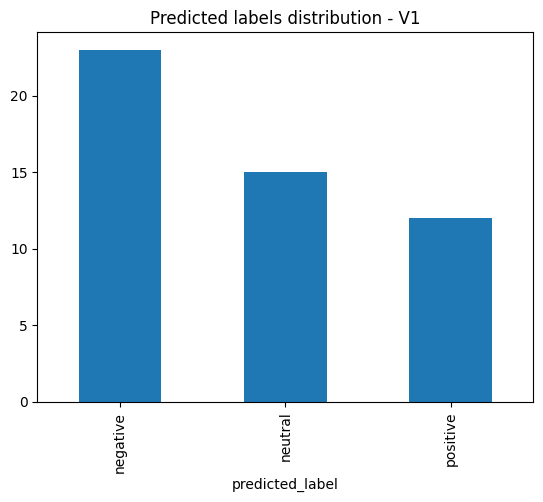

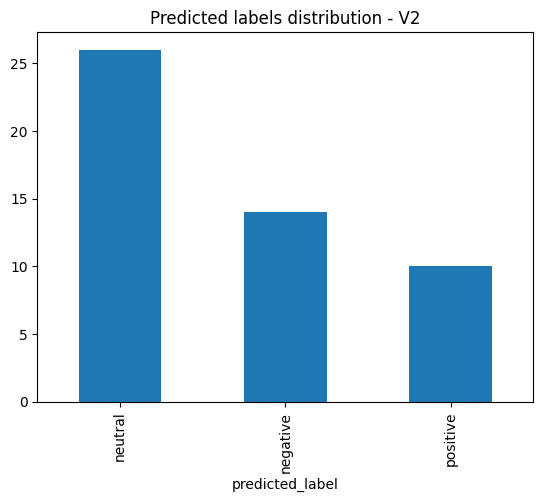

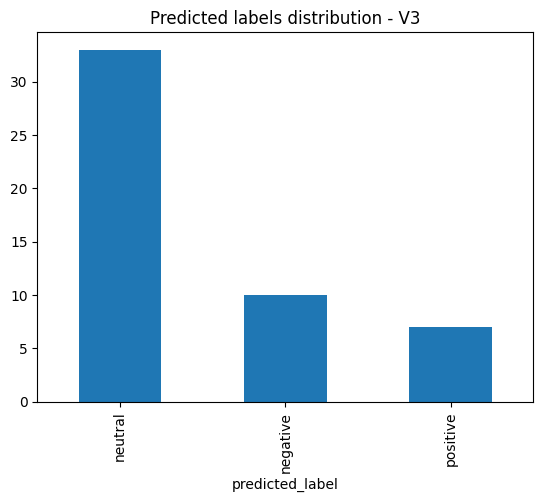

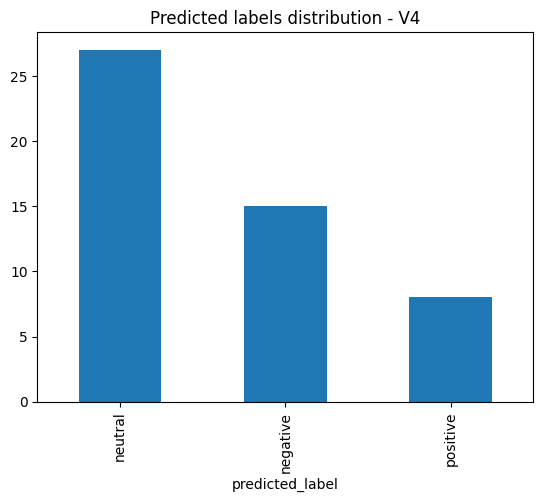

In [77]:
plot_label_distribution(results_dict)

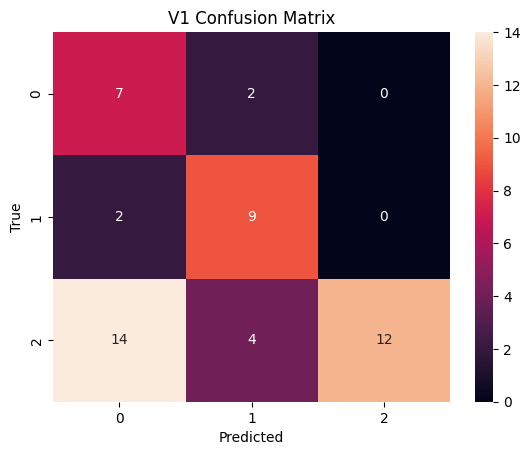

In [68]:
plot_confusion_matrix(results_v1, "V1 Confusion Matrix")

In [69]:
def get_errors(results_df):
    return results_df[
        results_df["true_label"] != results_df["predicted_label"]
    ]

In [70]:
errors_v1 = get_errors(results_v1)
errors_v2 = get_errors(results_v2)
errors_v3 = get_errors(results_v3)

In [71]:
errors_v1

,text,true_label,predicted_label,confidence
1,catch mig top clause accounting benefits modi ...,positive,neutral,0.70
2,haha reverse psychology pak want modi win,positive,negative,0.80
4,apology dictionary know well last time modi ap...,positive,negative,0.85
7,modi haters say nehrus rule drdo started lies ...,positive,negative,0.80
8,nirav modi get thousands crores many jobs crea...,positive,neutral,0.70
10,â shame modi bjp â election power cost cos...,positive,negative,0.85
14,multiple legal notices gone congress national ...,positive,negative,0.85
15,thop,positive,neutral,0.70
17,modishahmade constitutional institutionsto lic...,neutral,negative,0.85
21,looks like despite power five years narendra m...,positive,negative,0.85


In [72]:
print("V1 errors:", len(errors_v1))
print("V2 errors:", len(errors_v2))
print("V3 errors:", len(errors_v3))

V1 errors: 22
V2 errors: 27
V3 errors: 29


In [81]:
results_v4, metrics_v4 = run_experiment(
    "../prompts/prompt_V4.txt",
    "../results/results_V4.csv"
)

In [85]:
metrics_dict = {
    "V1": metrics_v1,
    "V2": metrics_v2,
    "V3": metrics_v3,
    "V4": metrics_v4
}

results_dict = {
    "V1": results_v1,
    "V2": results_v2,
    "V3": results_v3,
    "V4": results_v4
}

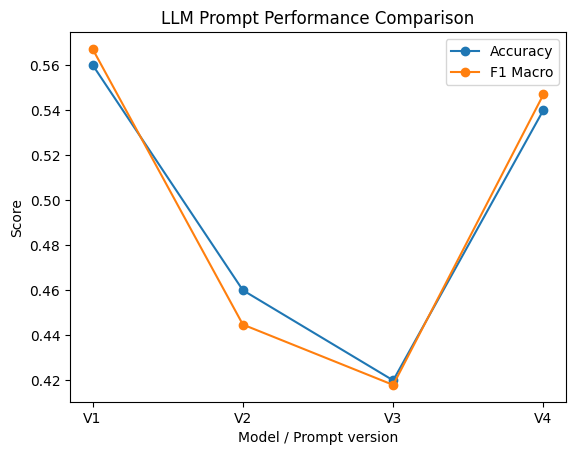

In [86]:
plot_global_metrics(metrics_dict)
